# 1 · Counting Photons: What is Quantum Light?

**Lecture · Monday July 27, 11:30–12:30 · Tim Thomay**

### Learning objectives

After this lecture you can:

1. explain why photon-**number statistics** distinguish light sources that have *identical* average intensity,
2. write down the photon number distribution $P(n)$ for **coherent**, **thermal**, and **Fock** states,
3. compute and interpret the **Mandel $Q$ parameter** as a witness of non-classical light.

*References: Fox, "Quantum Optics" Ch. 5 [Fox2006]; Gerry & Knight Ch. 3 [GerryKnight2005]; the original papers are in [`references.bib`](../references.bib).*

In [1]:
# Install packages if missing (needed on Google Colab; no-op in Codespaces).
import importlib.util, subprocess, sys
if importlib.util.find_spec("qutip") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "qutip"])

import numpy as np
import matplotlib.pyplot as plt
import qutip

# Course plot style: readable in the back row of the lecture hall.
plt.rcParams.update({"figure.figsize": (6, 4), "font.size": 12,
                     "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(42)  # reproducible "experiments"
print("qutip", qutip.__version__)

qutip 5.3.0


## 1.1 · Three light sources walk into a bar…

Take three sources, all attenuated to the **same average power** — say, an average of $\bar n = 4$ photons per detection window:

* a **laser** (coherent light),
* a **filtered lamp** / starlight (thermal or *chaotic* light),
* an ideal **single-photon-on-demand gun** fired 4 times per window (Fock states).

A classical power meter *cannot tell them apart*. But light arrives in discrete photons, and a **photon-counting detector** sees three completely different streams of clicks.

**The photon number distribution $P(n)$ — the probability of finding $n$ photons in a measurement window — is the fingerprint of a light source.** Today we learn to read the fingerprint; the rest of the course is about measuring it (Lectures 3–4) and engineering it (Lectures 5–6).

## 1.2 · One field mode = one harmonic oscillator

A single mode of the electromagnetic field (one frequency $\omega$, one direction, one polarization) is mathematically a quantum harmonic oscillator. Everything follows from the ladder operators:

$$[\hat a, \hat a^\dagger] = 1,\qquad \hat n = \hat a^\dagger \hat a,\qquad \hat H = \hbar\omega\left(\hat n + \tfrac12\right).$$

**Fock (number) states** $|n\rangle$ are the eigenstates of $\hat n$ — states with an *exactly defined* photon number:

$$\hat n |n\rangle = n|n\rangle, \qquad \hat a|n\rangle = \sqrt{n}\,|n-1\rangle, \qquad \hat a^\dagger|n\rangle = \sqrt{n+1}\,|n+1\rangle.$$

They are the natural basis for photon counting — but, perhaps surprisingly, **no natural light source emits Fock states**. The states that lasers and lamps produce are built *from* them:

| state | definition | photon number distribution $P(n)$ |
|---|---|---|
| **Fock** $\lvert n_0\rangle$ | $\hat n$ eigenstate | $P(n) = \delta_{n,n_0}$ |
| **coherent** $\lvert\alpha\rangle$ | $\hat a\lvert\alpha\rangle = \alpha\lvert\alpha\rangle$ | $P(n) = e^{-\bar n}\,\dfrac{\bar n^{\,n}}{n!}$ — **Poisson**, $\bar n = \lvert\alpha\rvert^2$ |
| **thermal** $\hat\rho_{\rm th}$ | max. entropy at fixed $\bar n$ | $P(n) = \dfrac{\bar n^{\,n}}{(1+\bar n)^{n+1}}$ — **Bose–Einstein** |

* The **coherent state** is the "most classical" pure state — the output of an ideal laser. It is a displaced vacuum: same minimal uncertainty, shifted in phase space.
* The **thermal state** is a *mixed* state — what you get from a lamp, a star ([HanburyBrown1956]), or (spoiler for Lecture 6!) from looking at *one arm* of a photon-pair source.

In [2]:
# Build the three states in QuTiP and read off P(n).
# QuTiP represents states in a truncated Fock space of dimension N:
# make N comfortably larger than any photon number we care about.
N = 100         # Fock-space cutoff; thermal states have long tails, and a
                # too-small cutoff silently biases variances - be generous
nbar = 4.0      # mean photon number, identical for all three sources

psi_fock = qutip.fock(N, int(nbar))          # |4>
psi_coh = qutip.coherent(N, np.sqrt(nbar))   # |alpha|^2 = nbar -> alpha = 2
rho_thermal = qutip.thermal_dm(N, nbar)      # mixed state, needs a density matrix

def photon_number_distribution(state) -> np.ndarray:
    """P(n) = diagonal of the density matrix in the Fock basis.

    Parameters
    ----------
    state : qutip.Qobj
        A ket or a density matrix of a single field mode.

    Returns
    -------
    np.ndarray
        P(n) for n = 0 .. N-1 (dimensionless probabilities, sum ~ 1).
    """
    rho = qutip.ket2dm(state) if state.isket else state
    return np.real(rho.diag())

for label, state in [("Fock   ", psi_fock),
                     ("coherent", psi_coh),
                     ("thermal ", rho_thermal)]:
    P = photon_number_distribution(state)
    mean = np.sum(np.arange(N) * P)
    print(f"{label}: <n> = {mean:.3f}   sum P(n) = {P.sum():.4f}")

Fock   : <n> = 4.000   sum P(n) = 1.0000
coherent: <n> = 4.000   sum P(n) = 1.0000
thermal : <n> = 4.000   sum P(n) = 1.0000


All three have $\bar n = 4$ — a power meter sees no difference. Now look at the *distributions*:

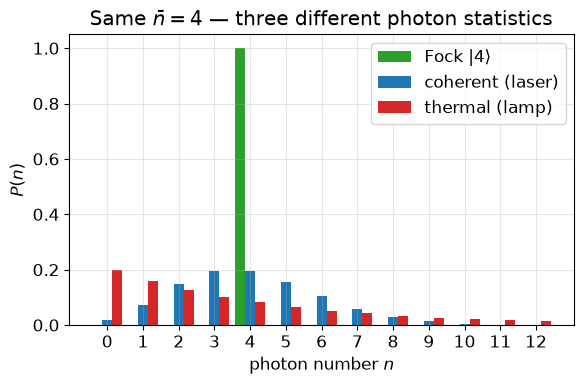

In [3]:
# THE key figure of this lecture: same mean, three different fingerprints.
n_axis = np.arange(13)
width = 0.28

fig, ax = plt.subplots()
for i, (label, state, color) in enumerate([
        ("Fock $|4\\rangle$", psi_fock, "tab:green"),
        ("coherent (laser)", psi_coh, "tab:blue"),
        ("thermal (lamp)", rho_thermal, "tab:red")]):
    P = photon_number_distribution(state)[:len(n_axis)]
    ax.bar(n_axis + (i - 1) * width, P, width, label=label, color=color)

ax.set_xlabel("photon number $n$")
ax.set_ylabel("$P(n)$")
ax.set_title(r"Same $\bar{n} = 4$ — three different photon statistics")
ax.set_xticks(n_axis)
ax.legend()
plt.tight_layout()
plt.show()

Read the fingerprints:

* **Fock**: a single spike. Zero uncertainty in photon number — maximal "quantumness" in $n$.
* **Coherent**: Poisson — the counting statistics of *independent random events*. Photons in laser light arrive like raindrops: no memory, no correlations.
* **Thermal**: geometric decay — $n=0$ is *always* the most likely outcome (!), yet the distribution has a long tail: huge fluctuations. Photons arrive in *bunches* (we will measure this on Tuesday).

## 1.3 · Quantifying the width: variance and the Mandel $Q$ parameter

The variance $(\Delta n)^2 = \langle \hat n^2\rangle - \langle \hat n\rangle^2$ of the three families:

$$(\Delta n)^2_{\rm Fock} = 0, \qquad (\Delta n)^2_{\rm coh} = \bar n, \qquad (\Delta n)^2_{\rm th} = \bar n + \bar n^2.$$

Mandel's $Q$ parameter [Mandel1979] measures the deviation from Poisson statistics:

$$\boxed{\;Q = \frac{(\Delta n)^2 - \bar n}{\bar n}\;}\qquad
\begin{cases}
Q = 0 & \text{Poissonian (coherent)}\\
Q > 0 & \text{super-Poissonian (thermal: } Q = \bar n)\\
-1 \le Q < 0 & \text{sub-Poissonian (Fock: } Q = -1)
\end{cases}$$

**Why we care:** any *classical* intensity distribution produces $Q \ge 0$ (a classical field can only *add* noise on top of Poissonian shot noise — this is a Cauchy–Schwarz argument, details Tuesday). Measuring $Q < 0$ is therefore **proof of non-classical light**. Sub-Poissonian statistics were first observed in resonance fluorescence of single atoms [Kimble1977, Mandel1979].

In [4]:
def mandel_Q(state) -> float:
    """Mandel Q parameter of a single-mode state.

    Q = (variance(n) - <n>) / <n>. Q=0 Poissonian, Q<0 sub-Poissonian
    (non-classical), Q>0 super-Poissonian.
    """
    N_dim = state.shape[0]
    n_op = qutip.num(N_dim)
    mean = qutip.expect(n_op, state)
    var = qutip.expect(n_op**2, state) - mean**2
    return (var - mean) / mean

for label, state in [("Fock |4>  ", psi_fock),
                     ("coherent  ", psi_coh),
                     ("thermal   ", rho_thermal)]:
    print(f"{label}: Q = {mandel_Q(state):+.3f}")

Fock |4>  : Q = -1.000
coherent  : Q = +0.000
thermal   : Q = +4.000


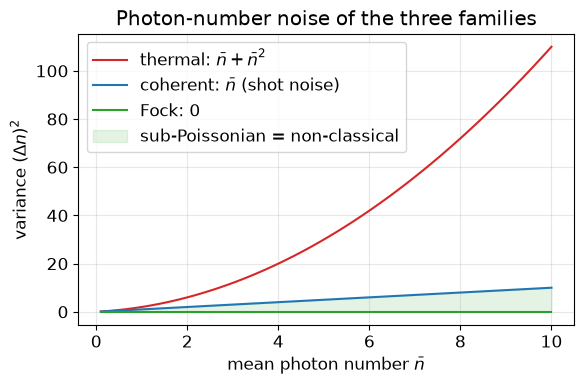

In [5]:
# Variance vs mean photon number - the three families as curves.
nbars = np.linspace(0.1, 10, 100)

fig, ax = plt.subplots()
ax.plot(nbars, nbars + nbars**2, color="tab:red", label="thermal: $\\bar{n}+\\bar{n}^2$")
ax.plot(nbars, nbars, color="tab:blue", label="coherent: $\\bar{n}$ (shot noise)")
ax.plot(nbars, 0 * nbars, color="tab:green", label="Fock: 0")
ax.fill_between(nbars, 0 * nbars, nbars, color="tab:green", alpha=0.12,
                label="sub-Poissonian = non-classical")
ax.set_xlabel(r"mean photon number $\bar{n}$")
ax.set_ylabel(r"variance $(\Delta n)^2$")
ax.set_title("Photon-number noise of the three families")
ax.legend()
plt.tight_layout()
plt.show()

## 1.4 · What the detector actually sees: click streams

$P(n)$ is an abstraction — a photon counter produces a **stream of time tags**. Here is a 2 ms simulated recording of our three sources (same average rate!). This is a preview of the Tuesday hands-on, where you will analyze exactly such data quantitatively.

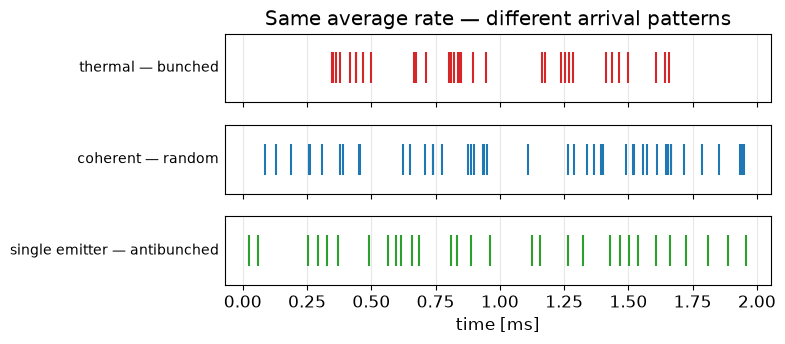

In [6]:
# Simulate 'click' arrival times (simplified versions of data/make_timetags.py).
rate = 20e3        # mean detected rate [clicks/s]
T_show = 2e-3      # displayed time window [s]

# coherent light: memoryless Poisson process
t_coherent = np.sort(rng.uniform(0, T_show, rng.poisson(rate * T_show)))

# thermal light: intensity fluctuates on the coherence time scale (bunching)
tau_c = 50e-6                                  # coherence time [s]
n_slots = int(T_show / tau_c)
intensity = rng.exponential(1.0, n_slots)      # single-mode thermal: I ~ exp
counts = rng.poisson(rate * tau_c * intensity)
t_thermal = np.sort(np.concatenate(
    [(k + rng.uniform(size=c)) * tau_c for k, c in enumerate(counts)]))

# single emitter: a dead time after every photon (antibunching)
gaps = rng.exponential(1 / rate, int(3 * rate * T_show)) + 20e-6  # 20 us dead time
t_emitter = np.cumsum(gaps)
t_emitter = t_emitter[t_emitter < T_show]

fig, axes = plt.subplots(3, 1, figsize=(8, 3.6), sharex=True)
for ax, (label, t, color) in zip(axes, [
        ("thermal — bunched", t_thermal, "tab:red"),
        ("coherent — random", t_coherent, "tab:blue"),
        ("single emitter — antibunched", t_emitter, "tab:green")]):
    ax.eventplot(t * 1e3, colors=color, linelengths=0.8)
    ax.set_yticks([])
    ax.set_ylabel(label, rotation=0, ha="right", va="center", fontsize=10)
axes[-1].set_xlabel("time [ms]")
axes[0].set_title("Same average rate — different arrival patterns")
plt.tight_layout()
plt.show()

Look closely: thermal clicks come in **clusters** (bunching), coherent clicks are **patternless**, and the single emitter keeps a minimum distance between clicks (**antibunching**) — it must be re-excited before it can emit again.

## 1.5 · Where do these states live in the lab?

| source | state | $Q$ | typical $\bar n$ per mode |
|---|---|---|---|
| laser above threshold | coherent | $0$ | anything you like |
| lamp, LED, star, ASE | thermal | $\bar n$ | $\ll 1$ (optical), $\gg 1$ (radio) |
| attenuated laser pulse | still coherent! | $0$ | $\sim 0.1$ (used in QKD) |
| single atom / molecule / quantum dot / NV center | approx. $\lvert 1\rangle$ | $\to -1$ | $\le 1$ |
| heralded SPDC (→ Lecture 6) | $\lvert 1\rangle$, $\lvert 2\rangle$, … | $\to -1$ | $\le 1$ |

Two traps worth remembering:

* **Attenuating a laser never makes single photons.** Loss thins a Poisson process into a sparser Poisson process — $Q$ stays $0$. A "0.1 photons per pulse" laser still has 2-photon events, which is why quantum key distribution had to invent decoy states.
* **Thermal light doesn't mean "hot".** It means *chaotic*: many independent emitters with random phases. A star is thermal; so is fluorescence from an ensemble, or one arm of a photon-pair source.

## 1.6 · Check your understanding

1. A detector integrates over many modes of thermal light. What happens to the measured $P(n)$, and why do you almost never *see* Bose–Einstein statistics with a photodiode in daylight? *(Hint: sum of many independent geometric variables.)*
2. You attenuate the Fock state $\lvert 4\rangle$ with 50% loss. Is the output still a Fock state? Is it still sub-Poissonian? *(We simulate exactly this in the afternoon.)*
3. Why is $Q = -1$ the most negative value possible?
4. A source emits $\lvert 1 \rangle$ with probability $p$ and vacuum otherwise. Compute $Q$. Is a lossy single-photon source still non-classical?

**This afternoon (14:00):** you build all of today's states yourself in QuTiP, sample detector clicks from them, and watch loss eat the quantumness — notebook [`02_HandsOn_SimulatingPhotonStatistics`](02_HandsOn_SimulatingPhotonStatistics.ipynb).